## Initial Setup & Downloads

In [7]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder

nltk.download('punkt')
nltk.download('stopwords')

# Download the "Emotions Dataset for NLP" directly from Kaggle
print("Downloading dataset from Kaggle...")
kaggle_path = kagglehub.dataset_download("praveengovi/emotions-dataset-for-nlp")
print("Downloaded from Kaggle to path:", kaggle_path)

# Path to train.txt inside the downloaded Kaggle directory
dataset_file = os.path.join(kaggle_path, "train.txt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using Colab cache for faster access to the 'emotions-dataset-for-nlp' dataset.
Downloaded from Kaggle to path: /kaggle/input/emotions-dataset-for-nlp


Q1. (Loading the Dataset)

Download the Emotions Dataset for NLP from Kaggle (or use the provided
train.txt).

Load the dataset using pandas with separator ; and column names ['text',
'emotions'].

Display the first 10 rows and the shape of the dataset.

Check for missing values using isnull().sum().

In [14]:
# 1. Load dataset using pandas with ';' separator and column names ['text', 'emotions']
df = pd.read_csv(dataset_file, sep=';', names=['text', 'emotions'])

# 2. Display first 10 rows
print("First 10 rows:")
display(df.head(10))

# 3. Display shape
print(f"\nShape of the dataset: {df.shape}")

# 4. Check for missing values
print("\nMissing values count:")
print(df.isnull().sum())

First 10 rows:


,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love



Shape of the dataset: (16000, 2)

Missing values count:
text        0
emotions    0
dtype: int64


Q2. (Exploring Target Labels)

Find and print all unique emotion labels present in the dataset.

Use LabelEncoder to convert the emotion labels into numeric values.

Create a dictionary mapping original emotion names to their encoded numbers
and display it.

Add the encoded labels as a new column in the DataFrame.

In [15]:
# 1. Print all unique emotion labels
unique_labels = df['emotions'].unique()
print("Unique Emotion Labels:", unique_labels)

# 2. Convert emotion labels into numeric values using LabelEncoder
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['emotions'])

# 3. Create mapping dictionary
label_map = dict(zip(le.classes_, range(len(le.classes_))))
print("\nEmotion to Encoded Number Mapping:")
print(label_map)

# 4. Display DataFrame with the new encoded column
display(df[['text', 'emotions', 'label_encoded']].head())

Unique Emotion Labels: ['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Emotion to Encoded Number Mapping:
{'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}


,text,emotions,label_encoded
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0


Q3. (Lowercasing)

Convert the entire text column to lowercase.

Show 5 sample texts before and after lowercasing.

Write a short note on why lowercasing is important in NLP.

In [16]:
# Save 5 sample texts before lowercasing
before_lower = df['text'].head(5).copy()

# Convert text column to lowercase
df['text_lower'] = df['text'].str.lower()

# Display 5 samples before and after
for i in range(5):
    print(f"Sample {i+1}:")
    print(f"  BEFORE: {before_lower.iloc[i]}")
    print(f"  AFTER : {df['text_lower'].iloc[i]}\n")

Sample 1:
  BEFORE: i didnt feel humiliated
  AFTER : i didnt feel humiliated

Sample 2:
  BEFORE: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  AFTER : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Sample 3:
  BEFORE: im grabbing a minute to post i feel greedy wrong
  AFTER : im grabbing a minute to post i feel greedy wrong

Sample 4:
  BEFORE: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  AFTER : i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Sample 5:
  BEFORE: i am feeling grouchy
  AFTER : i am feeling grouchy



Q4. (Removing Punctuation)

Write a function to remove all punctuation marks from the text.

Apply the function to the text column.

Display 5 examples before and after punctuation removal.

In [17]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply function
before_punc = df['text_lower'].head(5).copy()
df['text_no_punc'] = df['text_lower'].apply(remove_punctuation)

# Display 5 examples before and after
for i in range(5):
    print(f"Sample {i+1}:")
    print(f"  BEFORE: {before_punc.iloc[i]}")
    print(f"  AFTER : {df['text_no_punc'].iloc[i]}\n")

Sample 1:
  BEFORE: i didnt feel humiliated
  AFTER : i didnt feel humiliated

Sample 2:
  BEFORE: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  AFTER : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Sample 3:
  BEFORE: im grabbing a minute to post i feel greedy wrong
  AFTER : im grabbing a minute to post i feel greedy wrong

Sample 4:
  BEFORE: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  AFTER : i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Sample 5:
  BEFORE: i am feeling grouchy
  AFTER : i am feeling grouchy



Q5. (Removing Numbers)

Write a function that removes all digits from the text.

Apply it to the cleaned text column.

Show before and after examples.

In [18]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Apply function
before_num = df['text_no_punc'].head(5).copy()
df['text_no_num'] = df['text_no_punc'].apply(remove_numbers)

# Display before and after
for i in range(5):
    print(f"Sample {i+1}:")
    print(f"  BEFORE: {before_num.iloc[i]}")
    print(f"  AFTER : {df['text_no_num'].iloc[i]}\n")

Sample 1:
  BEFORE: i didnt feel humiliated
  AFTER : i didnt feel humiliated

Sample 2:
  BEFORE: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  AFTER : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Sample 3:
  BEFORE: im grabbing a minute to post i feel greedy wrong
  AFTER : im grabbing a minute to post i feel greedy wrong

Sample 4:
  BEFORE: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  AFTER : i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Sample 5:
  BEFORE: i am feeling grouchy
  AFTER : i am feeling grouchy



Q6. (Removing Emojis & Special Characters)

Write a function that keeps only ASCII characters (to remove emojis and special
symbols).

Apply the function to the text column.

Display a few examples of the cleaned text.

In [19]:
def remove_non_ascii(text):
    # Keeps only standard ASCII characters
    return text.encode('ascii', 'ignore').decode('utf-8')

# Apply function
df['text_ascii'] = df['text_no_num'].apply(remove_non_ascii)

# Display examples
for i in range(5):
    print(f"Cleaned Sample {i+1}: {df['text_ascii'].iloc[i]}")

Cleaned Sample 1: i didnt feel humiliated
Cleaned Sample 2: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Cleaned Sample 3: im grabbing a minute to post i feel greedy wrong
Cleaned Sample 4: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Cleaned Sample 5: i am feeling grouchy


Q7. (Removing Stopwords)

Download the necessary NLTK resources (punkt and stopwords).

Load English stopwords.

Write a function to remove stopwords from the text.

Apply the function and show 5 cleaned text samples.

In [20]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return " ".join(filtered)

# Apply function
df['text_no_stop'] = df['text_ascii'].apply(remove_stopwords)

# Display 5 cleaned samples
for i in range(5):
    print(f"Sample {i+1}: {df['text_no_stop'].iloc[i]}")

Sample 1: didnt feel humiliated
Sample 2: go feeling hopeless damned hopeful around someone cares awake
Sample 3: im grabbing minute post feel greedy wrong
Sample 4: ever feeling nostalgic fireplace know still property
Sample 5: feeling grouchy


Q8. (Complete Text Cleaning Pipeline)

Combine all the cleaning steps from Q3 to Q7 into a single cleaning function.

Apply the complete pipeline on the original text column.

Create a new column called cleaned_text.

Display the original text and cleaned text side by side for 10 samples.

In [21]:
def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Remove digits
    text = re.sub(r'\d+', '', text)
    # 4. Remove Non-ASCII / Emojis
    text = text.encode('ascii', 'ignore').decode('utf-8')
    # 5. Remove Stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# Apply complete pipeline
df['cleaned_text'] = df['text'].apply(clean_text)

# Display original and cleaned text side by side for 10 samples
display(df[['text', 'cleaned_text']].head(10))

,text,cleaned_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligrams times recommended amount...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas years feel petronas performed well ma...
9,i feel romantic too,feel romantic


Q9. (Text Length Analysis)

After cleaning:

Calculate the number of words in each cleaned text.
Plot a histogram of text lengths.

Print the average, minimum, and maximum text length.

Write observations about the cleaned data.

Average Text Length: 9.35 words
Minimum Text Length: 1 words
Maximum Text Length: 35 words


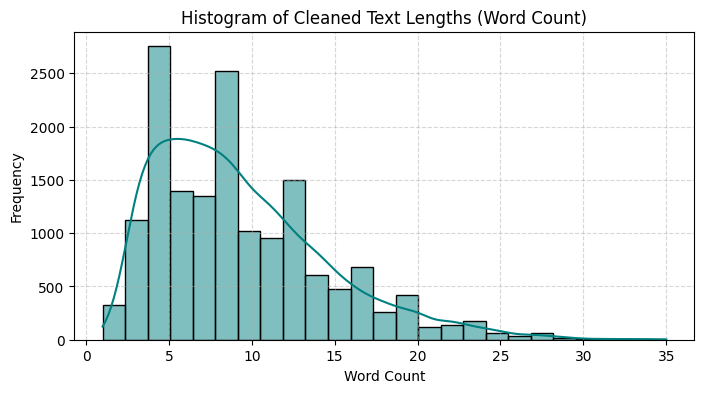

In [22]:
# Calculate word count for cleaned text
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# Calculate metrics
avg_len = df['word_count'].mean()
min_len = df['word_count'].min()
max_len = df['word_count'].max()

print(f"Average Text Length: {avg_len:.2f} words")
print(f"Minimum Text Length: {min_len} words")
print(f"Maximum Text Length: {max_len} words")

# Plot histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['word_count'], bins=25, kde=True, color='teal')
plt.title("Histogram of Cleaned Text Lengths (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Q10. (Mini Project – Full

Preprocessing Pipeline)
Using the Emotions Dataset:
1. Load the data
2. Encode the emotion labels
3. Perform complete text cleaning (lowercase → punctuation → numbers →
emojis → stopwords)
4. Save the cleaned dataset as cleaned_emotions.csv
5. Show value counts of each emotion

✅ Cleaned dataset successfully saved to 'cleaned_emotions.csv'

Value Counts for Each Emotion:
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


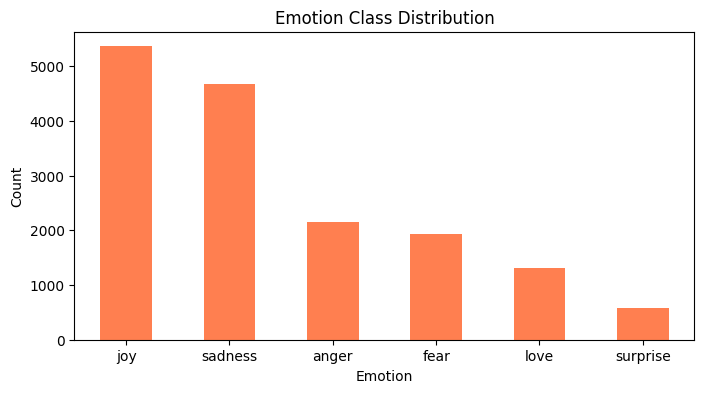

In [23]:
# 1. Load data & Encode labels (Completed in Q1 & Q2)
# 2. Perform complete text cleaning (Completed in Q8)

# 3. Save the cleaned dataset as cleaned_emotions.csv
output_df = df[['text', 'cleaned_text', 'emotions', 'label_encoded']]
output_df.to_csv('cleaned_emotions.csv', index=False)
print("✅ Cleaned dataset successfully saved to 'cleaned_emotions.csv'")

# 4. Show value counts of each emotion
print("\nValue Counts for Each Emotion:")
print(df['emotions'].value_counts())

# Plot distribution
plt.figure(figsize=(8, 4))
df['emotions'].value_counts().plot(kind='bar', color='coral')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()